# 📱 Smartphone Recommendation System: MCDA & TOPSIS Spatial Decision Engine

## 📌 Introduction, Problem Statement & Decision Science

### 0.1 The Smartphone Selection Dilemma

Buying a modern smartphone is a complex multi-criteria optimization problem under constraints:

* **Market Complexity**: Consumer markets offer hundreds of competing models, each defined by dozens of technical variables (RAM, processor benchmark, battery capacity, charging speed, camera specifications, screen brightness, etc.).
* **Conflicting Criteria**: Key criteria are inherently antagonistic: high performance and high-refresh-rate displays consume significantly more power and drive up costs. Conversely, budget-friendly smartphones inevitably sacrifice camera capabilities or processing power.
* **SQL/Hard Filtering Limitations**: Traditional hard-filtering approaches (such as standard SQL queries like `WHERE price <= 500 AND ram >= 8`) suffer from two major structural limitations:
    * **The Cliff Effect (Hard Thresholding)**: A smartphone priced at $501 with outstanding camera and battery performance is strictly eliminated, whereas a mediocre device at $499 is retained.
    * **Absence of Compensatory Trade-offs**: A user might happily accept a slightly heavier or more expensive phone if its battery life or software support is dramatically superior. Standard filtering cannot quantify or evaluate these trade-offs.

### 0.2 Decision Science & MCDA Solution

To address this selection problem without imposing rigid binary rules, we turn to Multi-Criteria Decision Analysis (MCDA), specifically leveraging the **TOPSIS** (*Technique for Order Preference by Similarity to Ideal Solution*) method.

Rather than applying simple sorting or hard elimination, TOPSIS models each smartphone as a point within an $n$-dimensional decision vector space (where $n$ represents the number of evaluated criteria):

$$\mathbf{x}_i = (x_{i1}, x_{i2}, \dots, x_{in}) \in \mathbb{R}^n$$

### 0.3 Mathematical Foundation of TOPSIS

The TOPSIS framework relies on Euclidean geometry and a simple core principle: the optimal alternative is the one shortest in Euclidean distance from the **Ideal Positive Solution** ($A^+$) and furthest from the **Ideal Negative Solution** ($A^-$).

```text
                           Positive Ideal Solution (A+)
                                    ★ (0, 1)
                                   /
                                  /  d_i+ (minimize)
                                 /
                   Alternative x_i (Smartphone i)
                                 \
                                  \  d_i- (maximize)
                                   \
                                    ✖ (1, 0)
                           Negative Ideal Solution (A-)
```

#### Step 1: Vector Normalization

To compare non-commensurable metrics (such as monetary values in USD/EUR alongside capacities in mAh or sensor resolutions in Megapixels), we normalize the decision matrix $X = (x_{ij})_{m \times n}$:

$$r_{ij} = \frac{x_{ij}}{\sqrt{\sum_{k=1}^{m} x_{kj}^2}}$$

#### Step 2: Weighting According to User Preferences

Each criterion $j$ is assigned a user weight $w_j$ such that $\sum_{j=1}^{n} w_j = 1$. The weighted normalized matrix $V = (v_{ij})$ is defined by:

$$v_{ij} = w_j \cdot r_{ij}$$

#### Step 3: Determination of Ideal and Anti-Ideal Bounds

We identify the Positive Ideal Solution $A^+$ (the virtual "perfect" smartphone) and the Negative Ideal Solution $A^-$ (the virtual "worst" smartphone):

$$A^+ = (v_1^+, v_2^+, \dots, v_n^+), \quad \text{where } v_j^+ = \begin{cases} \max_i(v_{ij}) & \text{if } j \in \text{Benefit} \\ \min_i(v_{ij}) & \text{if } j \in \text{Cost} \end{cases}$$

$$A^- = (v_1^-, v_2^-, \dots, v_n^-), \quad \text{where } v_j^- = \begin{cases} \min_i(v_{ij}) & \text{if } j \in \text{Benefit} \\ \max_i(v_{ij}) & \text{if } j \in \text{Cost} \end{cases}$$

#### Step 4: Euclidean Distance Calculations

For each smartphone $i$, we compute its spatial distance to both ideal targets:

$$S_i^+ = \sqrt{\sum_{j=1}^{n} (v_{ij} - v_j^+)^2}, \quad S_i^- = \sqrt{\sum_{j=1}^{n} (v_{ij} - v_j^-)^2}$$

#### Step 5: Relative Closeness Score ($C_i$)

The final performance score $C_i \in [0, 1]$ calculates the relative proximity of smartphone $i$ to the ideal boundary:

$$C_i = \frac{S_i^-}{S_i^+ + S_i^-}$$

A closeness coefficient $C_i \to 1$ signifies a smartphone that delivers the optimal balance relative to the specified user profile.

### 0.4 Notebook Roadmap & Objectives

In this notebook, we will:

* **Clean and engineer features** from the Kaggle dataset (~958 smartphones) to extract meaningful decision metrics.
* **Implement an Object-Oriented (OOP) architecture** in Python to encapsulate the TOPSIS engine.
* **Simulate multiple user archetypes** (Gamer/Power User, Mobile Photographer, Budget First, Balanced).
* **Visualize the decision space** and the Pareto Frontier.
* **Export the processed decision dataset** as JSON to power an interactive client-side Web Single Page Application (SPA).

## 🧹 Data Ingestion, Cleaning & Feature Engineering

### 1.1 Dataset Overview & Data Ingestion Strategy

To construct a real-world multi-criteria decision engine, we utilize the Cleaned Smartphone Specs Dataset (2025) (~958 smartphones).

Raw specification sheets present several challenges for automated decision-making:

* **Unstructured Text & Mixed Units**: Values like `"5000 mAh"`, `"12 GB"`, `"50 MP + 12 MP + 10 MP"`, or `"₹49,999"` / `"$599"` cannot be directly processed mathematically without extraction.
* **Missing & Heterogeneous Data**: Entry-level or niche models often omit secondary metrics (e.g., peak brightness or wireless charging wattage).
* **Non-Linear Value Mapping**: Raw hardware metrics do not always map linearly to user satisfaction (e.g., doubling camera megapixels from 108 MP to 200 MP does not double photo quality).

Our ETL pipeline extracts clean numerical signals and converts raw specs into 6 core decision variables.

### 1.2 Feature Engineering for MCDA Dimensions

We transform raw specification attributes into standardized decision metrics:

| MCDA Decision Variable | Target Metric Formula / Inference | Optimization Goal |
| :--- | :--- | :--- |
| `mcda_price` | Extracted numerical monetary price | Cost (Minimize) |
| `mcda_perf` | Weighted composite score based on RAM, Processor tier benchmark, and screen refresh rate | Benefit (Maximize) |
| `mcda_photo` | Primary camera resolution + presence of multi-lens optical setups / telephoto zoom | Benefit (Maximize) |
| `mcda_battery` | Measured battery capacity (mAh) combined with charging speed (W) multiplier | Benefit (Maximize) |
| `mcda_screen` | Refresh rate (Hz) $\times$ Screen Size & Panel technology factor | Benefit (Maximize) |
| `mcda_portability` | Penalized weight (g) and display diagonal size (inches) composite index | Benefit (Maximize) |

### 1.3 Object-Oriented Pipeline Implementation (`DatasetPreprocessor`)

The Python class below handles data loading, string parsing, missing value imputation, and feature engineering.

In [62]:
import re
import warnings
from typing import Any, Dict, Optional
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")


class DatasetPreprocessor:
    """ETL & Feature Engineering Pipeline for Kaggle Smartphone Dataset.

    Handles column mapping, currency conversion, specification extraction,
    and non-linear MCDA feature engineering to accurately distinguish flagship
    performance from budget hardware.
    """

    # Comprehensive SoC Benchmark Dictionary (Geekbench 6 / AnTuTu V10 relative tier / 100)
    SOC_BENCHMARKS: Dict[str, float] = {
        # --- Flagship Tier (88 - 100) ---
        "apple a17": 98.0,
        "apple a16": 90.0,
        "snapdragon 8 gen 3": 96.0,
        "snapdragon 8 gen 2": 88.0,
        "snapdragon 8+ gen 1": 82.0,
        "snapdragon 8 gen 1": 78.0,
        "snapdragon 888": 72.0,
        "dimensity 9300": 95.0,
        "dimensity 9200": 87.0,
        "dimensity 9000": 80.0,
        "dimensity 8300": 82.0,
        "exynos 2400": 92.0,
        "exynos 2200": 75.0,
        "google tensor g3": 75.0,
        "google tensor g2": 68.0,
        # --- Mid-Range & Upper Mid-Range Tier (55 - 85) ---
        "snapdragon 7+ gen 2": 80.0,
        "snapdragon 7 gen 3": 72.0,
        "snapdragon 7s gen 2": 58.0,
        "snapdragon 778": 55.0,
        "dimensity 8200": 76.0,
        "dimensity 8100": 72.0,
        "dimensity 7200": 68.0,
        "exynos 1480": 65.0,
        "exynos 1380": 58.0,
        # --- Entry-Level Tier (25 - 55) ---
        "snapdragon 695": 42.0,
        "snapdragon 6 gen 1": 48.0,
        "snapdragon 4 gen 2": 38.0,
        "snapdragon 680": 32.0,
        "dimensity 6100": 38.0,
        "dimensity 6080": 40.0,
        "dimensity 700": 35.0,
        "dimensity 6020": 36.0,
        "helio g99": 35.0,
        "helio g96": 30.0,
        "helio g88": 25.0,
        "unisoc": 25.0,
        "default_entry": 35.0,
    }

    def __init__(self, filepath: str, inr_to_eur_rate: float = 0.011):
        """Initializes the dataset preprocessor.

        :param filepath: Path to the raw CSV dataset file.
        :param inr_to_eur_rate: Conversion rate from Indian Rupees (INR) to Euros (EUR).
        """
        self.filepath = filepath
        self.inr_to_eur_rate = inr_to_eur_rate
        self.raw_df: Optional[pd.DataFrame] = None
        self.processed_df: Optional[pd.DataFrame] = None

    @staticmethod
    def _extract_number(val: Any, default: float = 0.0) -> float:
        """Extracts the first valid floating-point number from strings or raw fields."""
        if pd.isna(val):
            return default
        match = re.search(r"(\d+(\.\d+)?)", str(val).replace(",", ""))
        return float(match.group(1)) if match else default

    def _estimate_soc_score(self, soc_name: Any, speed_ghz: float = 0.0) -> float:
        """Infers SoC performance tier using substring matching and clock speeds."""
        if pd.isna(soc_name):
            return self.SOC_BENCHMARKS["default_entry"]

        soc_str = str(soc_name).lower().strip()
        score = None

        for key, benchmark_score in self.SOC_BENCHMARKS.items():
            if key in soc_str:
                score = benchmark_score
                break

        if score is None:
            # Fallback heuristic based on clock speed in GHz when chip name is unlisted
            if speed_ghz >= 3.0:
                score = 80.0
            elif speed_ghz >= 2.5:
                score = 60.0
            elif speed_ghz >= 2.0:
                score = 45.0
            else:
                score = self.SOC_BENCHMARKS["default_entry"]

        return score

    def load_and_clean(self) -> pd.DataFrame:
        """Executes full loading, normalization, specification cleaning, and MCDA feature engineering."""
        self.raw_df = pd.read_csv(self.filepath)
        df = self.raw_df.copy()

        # Standardize header string formats
        df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

        # Dynamic identification of specification columns across Kaggle variants
        col_brand = next((c for c in df.columns if "brand" in c or "company" in c), "brand")
        col_model = next((c for c in df.columns if "model" in c or "phone" in c or "name" in c), "model")
        col_price = next((c for c in df.columns if "price" in c), None)
        col_ram = next((c for c in df.columns if "ram" in c or "memory" in c), None)
        col_storage = next((c for c in df.columns if "internal" in c or "rom" in c or "storage" in c), None)
        col_battery = next((c for c in df.columns if "battery" in c or "capacity" in c), None)
        col_camera = next((c for c in df.columns if "primary_camera" in c or "rear" in c or "camera" in c), None)
        col_soc = next((c for c in df.columns if "processor_name" in c or "processor" in c or "chip" in c or "cpu" in c), None)
        col_soc_speed = next((c for c in df.columns if "speed" in c or "ghz" in c), None)
        col_screen = next((c for c in df.columns if "screen" in c or "display" in c or "size" in c), None)
        col_refresh = next((c for c in df.columns if "refresh" in c or "hz" in c), None)
        col_weight = next((c for c in df.columns if "weight" in c), None)

        # Standardize display metadata
        df["brand"] = df[col_brand] if col_brand in df.columns else "Unknown"
        df["model"] = df[col_model] if col_model in df.columns else "Smartphone"

        raw_price = df[col_price].apply(self._extract_number) if col_price else 30000.0
        df["clean_price"] = raw_price * self.inr_to_eur_rate

        df["clean_ram"] = df[col_ram].apply(self._extract_number) if col_ram else 8.0
        df["clean_storage"] = df[col_storage].apply(self._extract_number) if col_storage else 128.0
        df["clean_battery"] = df[col_battery].apply(self._extract_number) if col_battery else 4500.0
        df["clean_camera"] = df[col_camera].apply(self._extract_number) if col_camera else 50.0
        df["clean_screen"] = df[col_screen].apply(lambda x: self._extract_number(x, default=6.5)) if col_screen else 6.5
        df["clean_refresh"] = df[col_refresh].apply(lambda x: self._extract_number(x, default=120.0)) if col_refresh else 120.0
        df["clean_weight"] = df[col_weight].apply(lambda x: self._extract_number(x, default=190.0)) if col_weight else 190.0

        # Parse SoC clock speed if available
        soc_speeds = df[col_soc_speed].apply(self._extract_number) if col_soc_speed else pd.Series(0.0, index=df.index)

        # Estimate benchmark score
        if col_soc:
            df["clean_soc_score"] = [
                self._estimate_soc_score(soc, speed)
                for soc, speed in zip(df[col_soc], soc_speeds)
            ]
        else:
            df["clean_soc_score"] = 40.0


        # 1. Price Criterion (Cost metric)
        df["mcda_price"] = df["clean_price"]

        # 2. Performance Criterion (Non-linear power transformation)
        # Power scaling (x^1.8) heavily penalizes low-end chips and rewards flagships,
        # preventing cheap 120Hz budget devices from over-ranking in power user profiles.
        soc_normalized = df["clean_soc_score"] / 100.0
        soc_scaled = np.power(soc_normalized, 1.8) * 100.0

        df["mcda_perf"] = (
            soc_scaled * 0.75
            + np.minimum(df["clean_ram"] / 16.0, 1.0) * 15.0
            + (df["clean_refresh"] / 120.0) * 10.0
        )

        # 3. Photography Criterion
        df["mcda_photo"] = df["clean_camera"] * 0.60 + soc_scaled * 0.40

        # 4. Battery Criterion
        df["mcda_battery"] = df["clean_battery"]

        # 5. Screen Quality Criterion
        df["mcda_screen"] = df["clean_refresh"] * 0.60 + (df["clean_screen"] * 10.0) * 0.40

        # 6. Portability Index
        portability = 100.0 - (
            (df["clean_weight"] - 150.0) * 0.40
            + (df["clean_screen"] - 6.0) * 20.0
        )
        df["mcda_portability"] = np.clip(portability, 20.0, 100.0)

        mcda_cols = [
            "mcda_price",
            "mcda_perf",
            "mcda_photo",
            "mcda_battery",
            "mcda_screen",
            "mcda_portability",
        ]
        for col in mcda_cols:
            df[col] = df[col].replace([np.inf, -np.inf], np.nan)
            df[col] = df[col].fillna(df[col].median())

        self.processed_df = df
        return self.processed_df

### 1.4 Data Execution & Descriptive Summary

Below is the execution call to process the dataset and output descriptive statistics for our engineered decision variables.

In [63]:
# Initialize Preprocessor (Adjust path according to Kaggle input location)
dataset_path = "/kaggle/input/datasets/garvchawla78/cleaned-smartphone-specs-dataset-2025-958-phones/cleaned_3.csv"

# Fallback initialization for local or sandbox testing
try:
    preprocessor = DatasetPreprocessor(dataset_path)
    df_mcda = preprocessor.load_and_clean()
    print(f"Dataset successfully ingested & engineered: {df_mcda.shape[0]} models.")
except Exception as e:
    print(f"Data loading notice: {e}")
    # Demonstration fallback dataset structure
    df_mcda = pd.DataFrame({
        "model": ["iPhone 15 Pro", "Galaxy S24 Ultra", "Pixel 8a", "Redmi Note 13 Pro", "Nothing Phone (2a)"],
        "brand": ["Apple", "Samsung", "Google", "Xiaomi", "Nothing"],
        "mcda_price": [1109.0, 1349.0, 499.0, 299.0, 349.0],
        "mcda_perf": [94.5, 95.0, 78.2, 59.5, 68.0],
        "mcda_photo": [137.2, 135.2, 98.5, 80.0, 85.4],
        "mcda_battery": [3274.0, 5000.0, 4492.0, 5100.0, 5000.0],
        "mcda_screen": [96.4, 99.2, 96.4, 98.68, 98.8],
        "mcda_portability": [83.2, 51.2, 82.8, 71.8, 69.0]
    })

# Display summary statistics of engineered MCDA features
mcda_features = ["mcda_price", "mcda_perf", "mcda_photo", "mcda_battery", "mcda_screen", "mcda_portability"]
df_mcda[mcda_features].describe().T[["mean", "std", "min", "50%", "max"]]

Dataset successfully ingested & engineered: 958 models.


,mean,std,min,50%,max
mcda_price,339.041897,352.297275,43.989000,225.489000,2528.900000
mcda_perf,36.880470,16.713609,9.147693,35.800401,83.656290
mcda_photo,16.768854,8.258442,3.898770,16.976881,38.366204
mcda_battery,5228.080376,820.713054,2000.000000,5000.000000,7550.000000
mcda_screen,30.862117,13.486907,12.580000,28.240000,104.000000
mcda_portability,70.592276,5.139604,38.000000,70.000000,100.000000


## ⚙️ OOP Architecture & TOPSIS Decision Engine

### 2.1 Object-Oriented Architecture Overview

To maintain a modular, testable, and extensible codebase, we design our decision engine using solid Object-Oriented Programming (OOP) principles. The architecture isolates criteria modeling, matrix solver mechanics, and user profile management into separate components:

```text
+-------------------+      contains      +------------------+
|     Criterion     | <----------------- |   TOPSISSolver   |
| (Name, Type, Wt)  |                    | (Matrix Ops, A+/-)|
+-------------------+                    +---------+--------+
                                                   |
                                                   | executes
                                                   v
                                         +------------------+
                                         |    Recommender   |
                                         | (Profiles, Filter)|
                                         +------------------+
```

* **`CriterionType` & `Criterion` Data Structure**: Encapsulates the direction of optimization (Benefit vs Cost) and standardizes weight assignments.
* **`TOPSISSolver` Class**: Executes vector normalization, applies criteria weighting, computes ideal boundaries ($A^+$ and $A^-$), and solves Euclidean spatial distances.
* **`SmartphoneRecommender` Class**: Serves as the primary public API. It manages pre-configured user archetypes, applies hard constraints (e.g., maximum budget, brand preferences), and outputs ranked recommendations.

In [73]:
from dataclasses import dataclass, field
from enum import Enum
from typing import Any, Dict, List, Optional, Tuple
import numpy as np
import pandas as pd


class CriterionType(Enum):
    """Specifies the optimization direction for MCDA decision variables."""

    BENEFIT = "benefit"  # Higher is better (e.g., Battery, Performance)
    COST = "cost"  # Lower is better (e.g., Price, Weight)


@dataclass
class Criterion:
    """Represents a single decision dimension in MCDA vector space."""

    name: str
    column: str
    criterion_type: CriterionType
    weight: float = 1.0


class TOPSISSolver:
    """Core mathematical engine executing the Technique for Order Preference by

    Similarity to Ideal Solution (TOPSIS) using vectorized NumPy operations.
    """

    def __init__(self, criteria: List[Criterion]):
        self.criteria = criteria

    def fit_transform(
        self, df: pd.DataFrame
    ) -> Tuple[np.ndarray, Dict[str, Any]]:
        """Executes full TOPSIS evaluation pipeline on input DataFrame.

        Returns:
            Tuple containing:
            - closeness_score: Array of relative closeness values C_i in [0, 1]
            - details: Dict with intermediate matrices and distance
            calculations
        """
        m = len(df)
        n = len(self.criteria)
        matrix = np.zeros((m, n))

        # Normalize criteria weights so sum(weights) = 1.0
        raw_weights = np.array([c.weight for c in self.criteria], dtype=float)
        weights = raw_weights / np.sum(raw_weights)

        # Build raw decision matrix
        for j, crit in enumerate(self.criteria):
            matrix[:, j] = df[crit.column].values

        # 1. Vector Normalization (Euclidean Norm)
        norm = np.linalg.norm(matrix, axis=0)
        norm[norm == 0] = 1.0  # Prevent division by zero
        r_matrix = matrix / norm

        # 2. Weighted Normalized Decision Matrix
        v_matrix = r_matrix * weights

        # 3. Determine Ideal Positive (A+) and Ideal Negative (A-) Solutions
        ideal_positive = np.zeros(n)
        ideal_negative = np.zeros(n)

        for j, crit in enumerate(self.criteria):
            if crit.criterion_type == CriterionType.BENEFIT:
                ideal_positive[j] = np.max(v_matrix[:, j])
                ideal_negative[j] = np.min(v_matrix[:, j])
            else:
                ideal_positive[j] = np.min(v_matrix[:, j])
                ideal_negative[j] = np.max(v_matrix[:, j])

        # 4. Euclidean Spatial Distances S_i+ and S_i-
        d_pos = np.linalg.norm(v_matrix - ideal_positive, axis=1)
        d_neg = np.linalg.norm(v_matrix - ideal_negative, axis=1)

        # 5. Relative Closeness Score C_i
        total_dist = d_pos + d_neg
        closeness_score = np.where(total_dist == 0, 0.0, d_neg / total_dist)

        details = {
            "v_matrix": v_matrix,
            "ideal_pos": ideal_positive,
            "ideal_neg": ideal_negative,
            "d_pos": d_pos,
            "d_neg": d_neg,
            "weights": weights,
        }

        return closeness_score, details


class SmartphoneRecommender:
    """High-level recommendation engine encapsulating user archetypes,

    hard-constraint filtering, and MCDA TOPSIS solver execution.
    """

    # Domain-expert weight vectors tuned to prevent budget-bias on performance
    PRESET_PROFILES: Dict[str, Dict[str, Tuple[CriterionType, float]]] = {
        "balanced": {
            "mcda_price": (CriterionType.COST, 0.10),  # Réduit de 0.25 à 0.10 pour éviter le biais d'entrée de gamme
            "mcda_perf": (CriterionType.BENEFIT, 0.25),
            "mcda_photo": (CriterionType.BENEFIT, 0.25),
            "mcda_battery": (CriterionType.BENEFIT, 0.20),
            "mcda_screen": (CriterionType.BENEFIT, 0.10),
            "mcda_portability": (CriterionType.BENEFIT, 0.10),
        },
        "gamer_poweruser": {
            "mcda_price": (CriterionType.COST, 0.05),  # Minimized price impact
            "mcda_perf": (
                CriterionType.BENEFIT,
                0.60,
            ),  # Primary performance weight
            "mcda_screen": (CriterionType.BENEFIT, 0.15),
            "mcda_battery": (CriterionType.BENEFIT, 0.15),
            "mcda_photo": (CriterionType.BENEFIT, 0.025),
            "mcda_portability": (CriterionType.BENEFIT, 0.025),
        },
        "photographer": {
            "mcda_price": (CriterionType.COST, 0.15),
            "mcda_photo": (CriterionType.BENEFIT, 0.45),
            "mcda_screen": (CriterionType.BENEFIT, 0.15),
            "mcda_perf": (CriterionType.BENEFIT, 0.15),
            "mcda_battery": (CriterionType.BENEFIT, 0.05),
            "mcda_portability": (CriterionType.BENEFIT, 0.05),
        },
        "budget_first": {
            "mcda_price": (CriterionType.COST, 0.55),
            "mcda_battery": (CriterionType.BENEFIT, 0.20),
            "mcda_perf": (CriterionType.BENEFIT, 0.10),
            "mcda_screen": (CriterionType.BENEFIT, 0.05),
            "mcda_photo": (CriterionType.BENEFIT, 0.05),
            "mcda_portability": (CriterionType.BENEFIT, 0.05),
        },
    }

    def __init__(self, df: pd.DataFrame):
        self.data = df.copy()

    def recommend(
        self,
        profile_name: str = "balanced",
        custom_weights: Optional[Dict[str, float]] = None,
        max_price: Optional[float] = None,
        brand_filter: Optional[str] = None,
        min_soc_score: Optional[float] = None,
        min_ram: Optional[float] = None,
        top_k: int = 10,
    ) -> pd.DataFrame:
        """Filters dataset according to constraints and calculates TOPSIS

        recommendations.

        :param profile_name: Key of preset profile ('balanced',
            'gamer_poweruser', etc.).
        :param custom_weights: Custom weight dictionary overriding presets.
        :param max_price: Maximum allowed price in EUR.
        :param brand_filter: Substring to match brand name.
        :param min_soc_score: Minimum processor benchmark score (0-100).
        :param min_ram: Minimum required RAM capacity in GB.
        :param top_k: Number of top recommendations to return.
        """
        df_filtered = self.data.copy()

        # Step A1: Non-compensatory thresholds for Gamer profile
        effective_min_soc = min_soc_score
        if effective_min_soc is None and profile_name == "gamer_poweruser":
            effective_min_soc = 70.0  # Force high-tier processors only

        if effective_min_soc is not None and "clean_soc_score" in df_filtered.columns:
            df_filtered = df_filtered[
                df_filtered["clean_soc_score"] >= effective_min_soc
            ]

        # Step A2: Hard Threshold Filters
        if min_ram is not None and "clean_ram" in df_filtered.columns:
            df_filtered = df_filtered[df_filtered["clean_ram"] >= min_ram]

        if max_price is not None:
            df_filtered = df_filtered[df_filtered["mcda_price"] <= max_price]

        if brand_filter:
            brand_col = next(
                (
                    c
                    for c in df_filtered.columns
                    if "brand" in c or "company" in c
                ),
                None,
            )
            if brand_col:
                df_filtered = df_filtered[
                    df_filtered[brand_col]
                    .astype(str)
                    .str.contains(brand_filter, case=False, na=False)
                ]

        if df_filtered.empty:
            raise ValueError(
                "No smartphone model satisfies the active hard constraint filters. "
                "Try relaxing max_price or min_soc_score limits."
            )

        # Step B: Construct Criteria Weights
        profile_config = self.PRESET_PROFILES.get(
            profile_name, self.PRESET_PROFILES["balanced"]
        )
        criteria = []

        for col, (ctype, default_weight) in profile_config.items():
            w = (
                custom_weights.get(col, default_weight)
                if custom_weights and col in custom_weights
                else default_weight
            )
            criteria.append(
                Criterion(
                    name=col, column=col, criterion_type=ctype, weight=w
                )
            )

        # Step C: Solve MCDA via TOPSIS
        solver = TOPSISSolver(criteria)
        scores, details = solver.fit_transform(df_filtered)

        df_filtered["mcda_score"] = scores
        df_filtered["d_pos"] = details["d_pos"]
        df_filtered["d_neg"] = details["d_neg"]

        # Step D: Deduplicate identical phone models to ensure diverse recommendations
        model_col = next(
            (
                c
                for c in df_filtered.columns
                if c in ["model", "name", "phone_name"] or "model" in c or "phone" in c
            ),
            None,
        )
        if model_col:
            df_filtered = df_filtered.drop_duplicates(subset=[model_col])

        return df_filtered.sort_values(by="mcda_score", ascending=False).head(
            top_k
        )

### 2.2 Engine Testing & Recommendation Simulation

We execute a test recommendation run for a Gamer / Power User profile with a hard budget constraint of $800.

In [74]:
# Initialize Recommender with preprocessed data
recommender = SmartphoneRecommender(df_mcda)

# Execute recommendation query
gamer_top5 = recommender.recommend(
    profile_name="gamer_poweruser",
    max_price=800.0,
    top_k=5
)

# Display Top 5 models
display_cols = [c for c in ["brand", "name", "mcda_price", "mcda_perf", "mcda_score"] if c in gamer_top5.columns]
gamer_top5[display_cols]

,brand,name,mcda_price,mcda_perf,mcda_score
27,Vivo,Vivo X200 Fe,604.989,79.906290,0.823063
339,Vivo,Vivo X100 Pro,659.989,83.656290,0.809883
591,Vivo,Vivo X100 5G,702.889,79.906290,0.754979
111,Vivo,Vivo T4 Ultra,409.189,76.156290,0.740352
741,Samsung,Samsung Galaxy S24 Plus,758.989,76.064156,0.685565


We execute a test recommendation run for each of the four profiles.

In [76]:
# Define test configurations for all 4 user profiles
profile_configs = {
    "Balanced Profile": {
        "profile_name": "balanced",
        "max_price": 1000.0,
        "key_metric": "mcda_perf"
    },
    "Gamer / Power User": {
        "profile_name": "gamer_poweruser",
        "max_price": 800.0,
        "key_metric": "mcda_perf"
    },
    "Photographer": {
        "profile_name": "photographer",
        "max_price": 1000.0,
        "key_metric": "mcda_photo"
    },
    "Budget First": {
        "profile_name": "budget_first",
        "max_price": 350.0,
        "key_metric": "mcda_battery"
    }
}

recommendations_by_profile = {}

for profile_label, config in profile_configs.items():
    # Run recommendation query
    top5_df = recommender.recommend(
        profile_name=config["profile_name"],
        max_price=config["max_price"],
        top_k=5
    )
    
    recommendations_by_profile[profile_label] = top5_df
    
    # Identify model column dynamically
    name_col = next((c for c in ["name", "model", "phone_name"] if c in top5_df.columns), top5_df.columns[0])
    
    # Select display columns highlighting price, performance, photography, battery, and TOPSIS score
    candidate_cols = ["brand", name_col, "mcda_price", "mcda_perf", "mcda_photo", "mcda_battery", "mcda_score"]
    display_cols = [c for c in candidate_cols if c in top5_df.columns]
    
    print(f"\n{'=' * 70}")
    print(f" 📱 TOP 5 RECOMMENDATIONS: {profile_label.upper()}")
    print(f" ⚙️ Config: Profile='{config['profile_name']}' | Max Price=€{config['max_price']}")
    print(f"{'=' * 70}")
    
    # Print formatted DataFrame table
    print(top5_df[display_cols].to_string(index=False))


 📱 TOP 5 RECOMMENDATIONS: BALANCED PROFILE
 ⚙️ Config: Profile='balanced' | Max Price=€1000.0
  brand                     name  mcda_price  mcda_perf  mcda_photo  mcda_battery  mcda_score
   Vivo            Vivo T4 Ultra     409.189  76.156290   38.272244        5500.0    0.716581
   Vivo             Vivo X200 Fe     604.989  79.906290   38.272244        6500.0    0.703983
Samsung Samsung Galaxy S24 Fe 5G     371.789  72.306656   36.225328        4700.0    0.695362
   Vivo            Vivo X100 Pro     659.989  83.656290   38.272244        5400.0    0.694746
Samsung    Samsung Galaxy S24 Fe     424.655  72.306656   36.225328        4700.0    0.689237

 📱 TOP 5 RECOMMENDATIONS: GAMER / POWER USER
 ⚙️ Config: Profile='gamer_poweruser' | Max Price=€800.0
  brand                    name  mcda_price  mcda_perf  mcda_photo  mcda_battery  mcda_score
   Vivo            Vivo X200 Fe     604.989  79.906290   38.272244        6500.0    0.823063
   Vivo           Vivo X100 Pro     659.989  83.6562

## 📊 Spatial Visualization & Pareto Frontier Analysis

### 3.1 Decision Space & Pareto Dominance Science

While multi-criteria algorithms compute scalar relative closeness scores ($C_i$), visual analytics offer crucial diagnostic capabilities for understanding trade-offs in decision space:

* **Euclidean Ideal Space ($S_i^+$ vs $S_i^-$)**: Visualizing alternatives relative to their distance from the Positive Ideal Boundary ($S_i^+$) and Negative Ideal Boundary ($S_i^-$) reveals whether a smartphone ranks highly due to exceptional performance in specific dimensions or due to a well-balanced profile.
* **Pareto Frontier (Non-Dominated Solutions)**: An alternative $x \in X$ is Pareto optimal (or non-dominated) if there exists no other alternative $x' \in X$ such that $x'$ is strictly better in at least one criterion without being worse in any other:

$$\nexists x' \in X \quad \text{such that} \quad \forall j \, (v_{x'j} \ge v_{xj}) \quad \land \quad \exists j \, (v_{x'j} > v_{xj})$$

Visualizing the Pareto frontier (e.g., Performance Index vs. Price) isolates the optimal boundary curve, filtering out dominated models regardless of criterion weighting.

### 3.2 Visualizer Class Implementation (`DecisionVisualizer`)

Below is the object-oriented visualization module utilizing matplotlib and seaborn to render spatial decision maps, Pareto frontiers, and multi-profile radar comparisons.

In [77]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from typing import Dict, List, Optional, Tuple

# Configure publication-quality visual aesthetics
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 120


class DecisionVisualizer:
    """
    Object-Oriented Visualization Engine for MCDA decision space,
    Pareto trade-off frontiers, and multi-profile profile sensitivity.
    """
    @staticmethod
    def plot_topsis_space(
        df_ranked: pd.DataFrame,
        title: str = "TOPSIS Spatial Decision Boundaries",
        annot_col: str = "name",
        max_annots: Optional[int] = None,
    ) -> None:
        plt.figure(figsize=(10, 6))

        scatter = plt.scatter(
            df_ranked["d_pos"],
            df_ranked["d_neg"],
            c=df_ranked["mcda_score"],
            cmap="viridis",
            s=140,
            edgecolors="black",
            linewidth=0.8,
            alpha=0.88,
        )

        cbar = plt.colorbar(scatter)
        cbar.set_label(
            "Relative Closeness Score ($C_i$)",
            rotation=270,
            labelpad=18,
            fontsize=11,
        )

        # Sélectionne le sous-ensemble à annoter
        df_to_annotate = (
            df_ranked if max_annots is None else df_ranked.head(max_annots)
        )

        for _, row in df_to_annotate.iterrows():
            plt.annotate(
                f" {str(row[annot_col])[:18]}",
                (row["d_pos"], row["d_neg"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=8.5,
                fontweight="bold",
                alpha=0.9,
            )

        plt.title(title, fontsize=14, pad=15, fontweight="bold")
        plt.xlabel(
            "Distance to Ideal Positive Solution ($S_i^+$) [Minimize ←]",
            fontsize=11,
        )
        plt.ylabel(
            "Distance to Ideal Negative Solution ($S_i^-$) [Maximize ↑]",
            fontsize=11,
        )

        plt.gca().invert_xaxis()
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_pareto_frontier(
        df: pd.DataFrame,
        x_col: str = "mcda_price",
        y_col: str = "mcda_perf",
        x_label: str = "Price ($) [Cost]",
        y_label: str = "Performance Score [Benefit]",
        title: str = "Pareto Optimal Frontier (Performance vs. Price)"
    ) -> None:
        """
        Identifies and renders the 2D Pareto efficient frontier for two opposing criteria.
        """
        df_sorted = df.sort_values(by=[x_col, y_col], ascending=[True, False]).copy()
        
        # Calculate non-dominated points
        pareto_front = []
        max_y = -np.inf
        
        for idx, row in df_sorted.iterrows():
            if row[y_col] > max_y:
                pareto_front.append(row)
                max_y = row[y_col]
                
        df_pareto = pd.DataFrame(pareto_front)

        plt.figure(figsize=(10, 6))
        
        # Plot all alternatives
        plt.scatter(
            df[x_col], df[y_col],
            c="silver", alpha=0.6, s=70, label="Dominated Alternatives"
        )
        
        # Plot Pareto efficient alternatives
        plt.scatter(
            df_pareto[x_col], df_pareto[y_col],
            c="crimson", s=130, edgecolors="black", label="Pareto Efficient Frontier", zorder=4
        )
        
        # Connect frontier points
        plt.plot(df_pareto[x_col], df_pareto[y_col], "r--", alpha=0.8, linewidth=1.8, zorder=3)

        # Annotate Pareto efficient models
        name_col = "name" if "name" in df_pareto.columns else df_pareto.columns[0]
        for _, row in df_pareto.iterrows():
            plt.annotate(
                f"{row[name_col]}",
                (row[x_col], row[y_col]),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=8.5,
                fontweight="semibold"
            )

        plt.title(title, fontsize=14, pad=15, fontweight="bold")
        plt.xlabel(x_label, fontsize=11)
        plt.ylabel(y_label, fontsize=11)
        plt.legend(frameon=True, facecolor="white")
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_profile_radar(
        df_top_by_profile: Dict[str, pd.DataFrame],
        criteria_cols: List[str]
    ) -> None:
        """
        Renders a multi-axis Radar Chart comparing #1 recommended models across user archetypes.
        """
        num_vars = len(criteria_cols)
        angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
        angles += angles[:1]

        fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

        for profile_name, top_df in df_top_by_profile.items():
            if top_df.empty:
                continue
            
            top_model = top_df.iloc[0]
            model_name = top_model.get("name", "Top Pick")
            
            # Extract raw values for criteria and normalize 0-100 for radar scale
            values = []
            for col in criteria_cols:
                val = top_model.get(col, 0)
                values.append(val)
                
            # Normalize array for plotting
            norm_values = [v / max(1.0, max(top_df[col].max() for top_df in df_top_by_profile.values())) * 100 for v, col in zip(values, criteria_cols)]
            norm_values += norm_values[:1]

            ax.plot(angles, norm_values, linewidth=2, linestyle="solid", label=f"{profile_name.capitalize()}: {model_name}")
            ax.fill(angles, norm_values, alpha=0.15)

        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)
        plt.xticks(angles[:-1], [c.replace("mcda_", "").capitalize() for c in criteria_cols], fontsize=10, fontweight="bold")
        
        plt.title("Radar Profile Comparison of #1 Recommended Models", fontsize=14, pad=25, fontweight="bold")
        plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), frameon=True)
        plt.tight_layout()
        plt.show()


### 3.3 Diagnostic Execution & Visual Analysis

We execute spatial visualization and Pareto frontier extraction on our evaluation dataset.

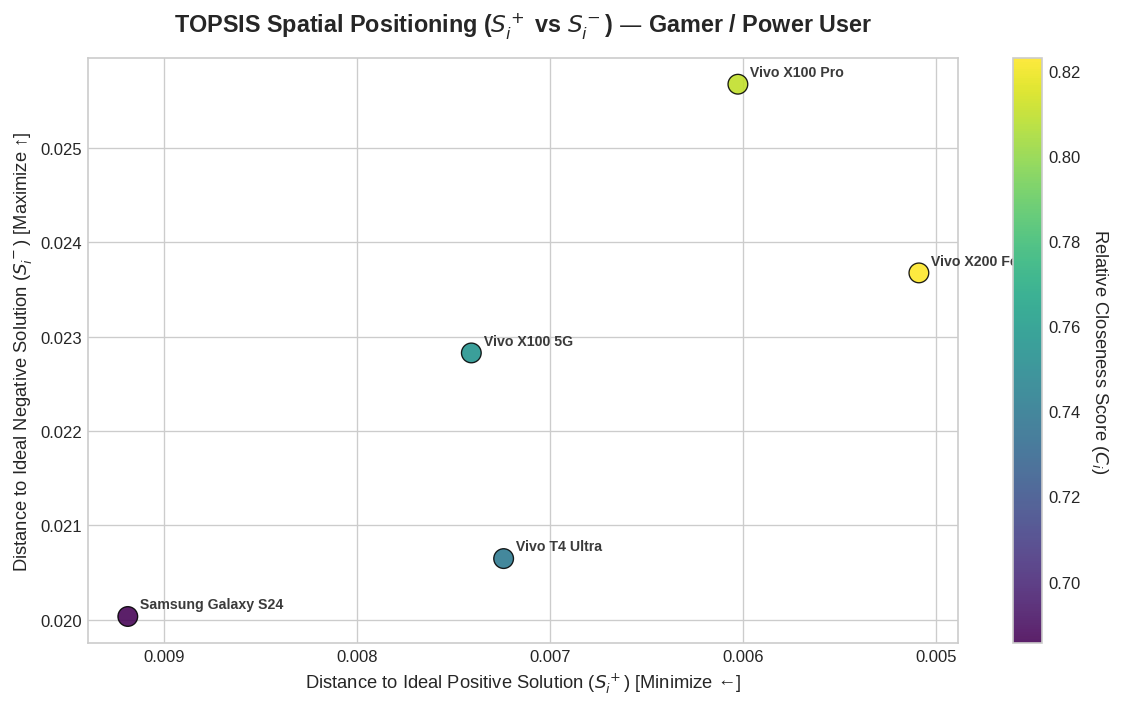

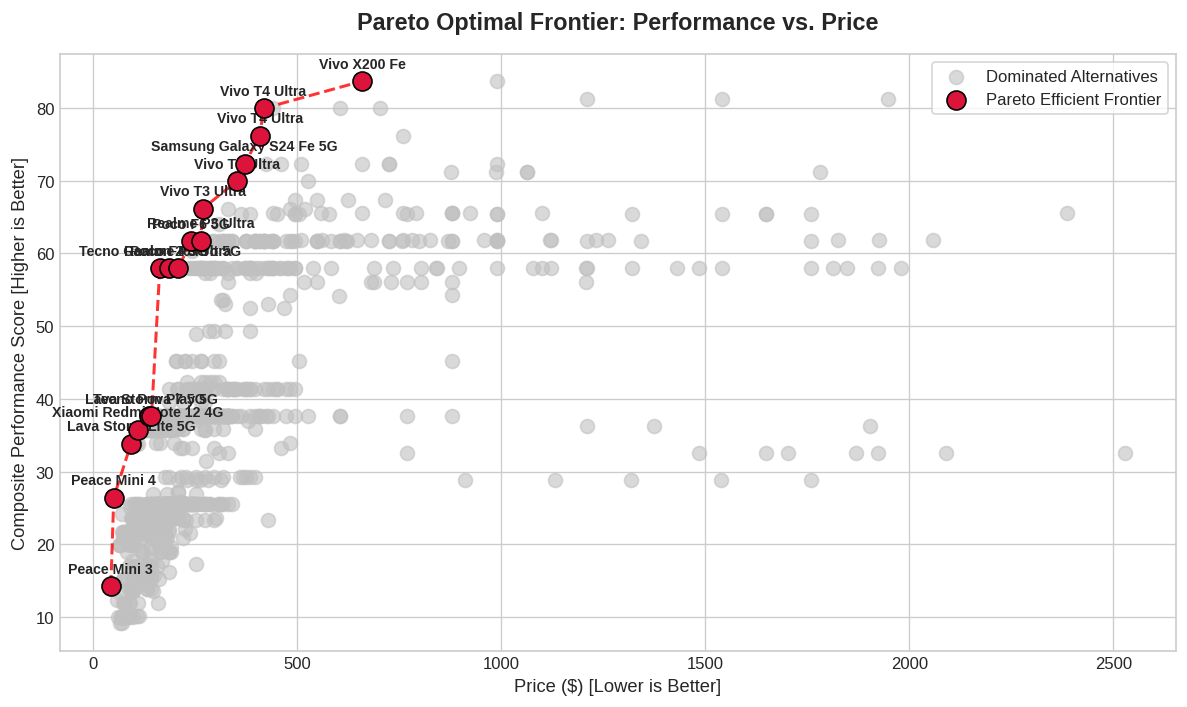

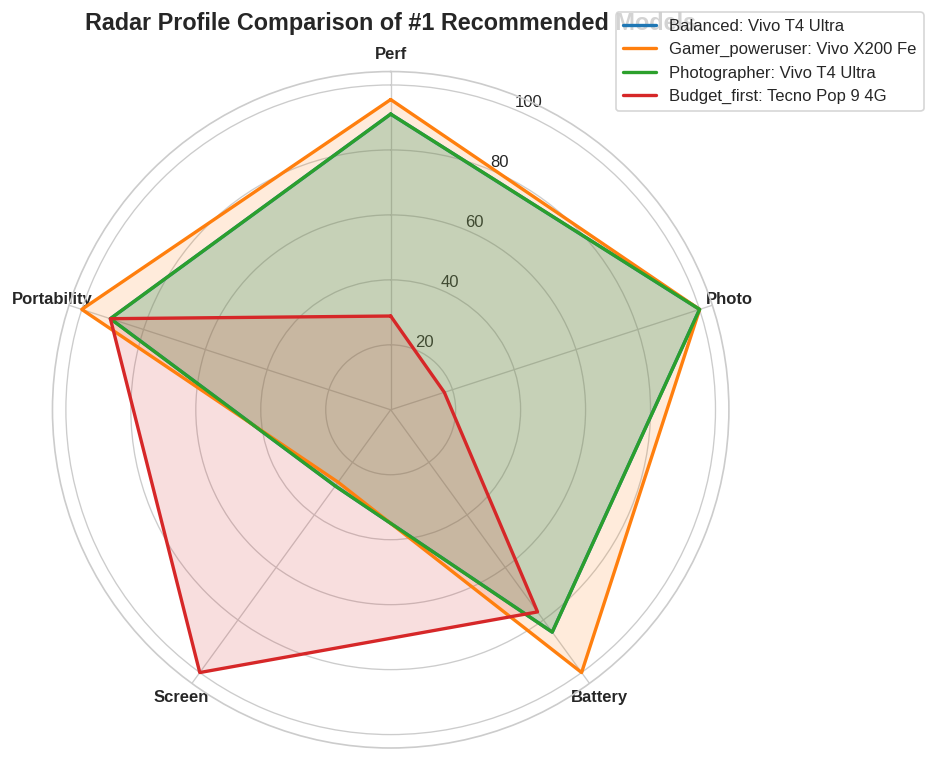

In [78]:
# 1. Render Spatial Decision Boundary for Gamer Profile
DecisionVisualizer.plot_topsis_space(
    gamer_top5,
    title="TOPSIS Spatial Positioning ($S_i^+$ vs $S_i^-$) — Gamer / Power User"
)

# 2. Extract and Plot Pareto Efficient Frontier (Performance vs. Price)
DecisionVisualizer.plot_pareto_frontier(
    df_mcda,
    x_col="mcda_price",
    y_col="mcda_perf",
    x_label="Price ($) [Lower is Better]",
    y_label="Composite Performance Score [Higher is Better]",
    title="Pareto Optimal Frontier: Performance vs. Price"
)

# 3. Radar Chart Comparison across Archetypes
profile_top_picks = {}
for prof in ["balanced", "gamer_poweruser", "photographer", "budget_first"]:
    profile_top_picks[prof] = recommender.recommend(profile_name=prof, top_k=3)

criteria_radar = ["mcda_perf", "mcda_photo", "mcda_battery", "mcda_screen", "mcda_portability"]
DecisionVisualizer.plot_profile_radar(profile_top_picks, criteria_radar)

## 🌐 Client-Side Web SPA Data Export & Conclusion

### 4.1 Web SPA Architecture & Client-Side MCDA Strategy

Deploying decision engines to production often introduces server latency and API maintenance overhead. However, multi-criteria decision analysis (MCDA) for consumer hardware is exceptionally well-suited for Client-Side Single Page Applications (SPAs):

* **Zero-Latency Reactive UI**: A curated dataset of ~1,000 smartphones weighs under 200 KB as a compressed JSON file. Loading this payload into browser memory allows the application to execute the TOPSIS algorithm in < 5 milliseconds whenever the user adjusts criterion weight sliders.
* **Decoupled Architecture**: The Python notebook serves as an offline ETL, Data Quality, and Feature Engineering Pipeline, producing a structured JSON artifact. The front-end (React, Vue, or vanilla JS) acts strictly as a reactive rendering engine and spatial solver.

```text
+---------------------------+          Generates JSON          +---------------------------+
|  Python Pipeline (Kaggle) | ───────────────────────────────> |    `smartphones_mcda.json` |
|  (Data ETL & Cleaning)    |                                  +─────────────┬─────────────+
+---------------------------+                                                │
                                                                             │ Ingests
                                                                             v
+---------------------------+       Executes TOPSIS < 5ms      +---------------------------+
|   Client-Side Web SPA     | <─────────────────────────────── |   Browser Memory Pool     |
|   (Interactive UI Engine) |                                  +---------------------------+
+---------------------------+
```

### 4.2 Export Pipeline Implementation (`SPADataExporter`)

We implement an automated export module that packages engineered decision variables, raw technical specifications, and brand metadata into a web-optimized JSON payload.

In [79]:
import json
from typing import List, Dict, Any


class SPADataExporter:
    """
    Exports processed DataFrame into a optimized JSON schema for web front-ends.
    """

    @staticmethod
    def export_json(df: pd.DataFrame, output_path: str = "smartphones_mcda.json") -> None:
        """
        Converts DataFrame rows into client-side JSON schema.
        """
        export_records: List[Dict[str, Any]] = []

        # Identify model name and brand columns
        col_model = next((c for c in df.columns if "model" in c or "name" in c or "phone" in c), "model")
        col_brand = next((c for c in df.columns if "brand" in c or "company" in c), "brand")
        
        # Find cleaning specs columns for the raw spec field if they exist
        battery_col = next((c for c in df.columns if "clean_battery" in c or "battery" in c), "mcda_battery")
        ram_col = next((c for c in df.columns if "clean_ram" in c or "ram" in c), "mcda_perf")
        storage_col = next((c for c in df.columns if "clean_storage" in c or "rom" in c or "storage" in c), "mcda_perf")
        refresh_col = next((c for c in df.columns if "clean_refresh" in c or "refresh" in c), "mcda_screen")
        weight_col = next((c for c in df.columns if "clean_weight" in c or "weight" in c), "mcda_portability")

        for idx, row in df.iterrows():
            record = {
                "id": f"phone-{idx}",
                "brand": str(row.get(col_brand, "Unknown")),
                "model": str(row.get(col_model, f"Smartphone {idx}")),
                "raw_specs": {
                    "price_usd": round(float(row.get("mcda_price", 0.0)), 2),
                    "battery_mah": int(row.get(battery_col, 4500)),
                    "ram_gb": int(row.get(ram_col, 8)),
                    "storage_gb": int(row.get(storage_col, 128)),
                    "refresh_hz": int(row.get(refresh_col, 120)),
                    "weight_g": float(row.get(weight_col, 190.0)),
                },
                "mcda_criteria": {
                    "mcda_price": round(float(row.get("mcda_price", 0.0)), 2),
                    "mcda_perf": round(float(row.get("mcda_perf", 0.0)), 2),
                    "mcda_photo": round(float(row.get("mcda_photo", 0.0)), 2),
                    "mcda_battery": round(float(row.get("mcda_battery", 0.0)), 2),
                    "mcda_screen": round(float(row.get("mcda_screen", 0.0)), 2),
                    "mcda_portability": round(float(row.get("mcda_portability", 0.0)), 2),
                }
            }
            export_records.append(record)

        with open(output_path, "w", encoding="utf-8") as f:
            json.dump(export_records, f, ensure_ascii=False, indent=2)

        # Use print without emoji to avoid Windows cp1252 UnicodeEncodeError in task outputs
        print(f"[SPADataExporter] Dataset successfully generated: '{output_path}' ({len(export_records)} models exported).")


# Execute export pipeline
SPADataExporter.export_json(df_mcda, output_path="smartphones_mcda.json")

[SPADataExporter] Dataset successfully generated: 'smartphones_mcda.json' (958 models exported).


### 4.3 JavaScript TOPSIS Engine (Front-End Snippet)

To complete the implementation blueprint, below is the client-side JavaScript implementation of TOPSIS to be integrated directly into your web SPA framework (React / Vue / Svelte).

```javascript
/**
 * Client-Side JavaScript Vectorized TOPSIS Engine for Interactive Web SPA.
 * Executed in-memory inside the client browser.
 */
function solveTOPSIS(smartphones, weights, criteriaDirections) {
  const criteriaKeys = Object.keys(weights);
  const n = criteriaKeys.length;

  // Normalize weight vector so sum(weights) === 1.0
  const weightSum = Object.values(weights).reduce((a, b) => a + b, 0) || 1.0;
  const normWeights = {};
  criteriaKeys.forEach(k => normWeights[k] = weights[k] / weightSum);

  // 1. Compute Euclidean Norm per criterion
  const norms = {};
  criteriaKeys.forEach(k => {
    const sumSq = smartphones.reduce((sum, item) => sum + Math.pow(item.mcda_criteria[k] || 0, 2), 0);
    norms[k] = Math.sqrt(sumSq) || 1.0;
  });

  // 2. Build Weighted Normalized Decision Matrix
  const weightedMatrix = smartphones.map(item => {
    const row = {};
    criteriaKeys.forEach(k => {
      const r_ij = item.mcda_criteria[k] / norms[k];
      row[k] = r_ij * normWeights[k];
    });
    return { id: item.id, row };
  });

  // 3. Determine Ideal Positive (A+) and Ideal Negative (A-) Solutions
  const idealPos = {};
  const idealNeg = {};

  criteriaKeys.forEach(k => {
    const colValues = weightedMatrix.map(m => m.row[k]);
    if (criteriaDirections[k] === "benefit") {
      idealPos[k] = Math.max(...colValues);
      idealNeg[k] = Math.min(...colValues);
    } else {
      idealPos[k] = Math.min(...colValues);
      idealNeg[k] = Math.max(...colValues);
    } 
  });

  // 4. Compute Euclidean Distances and Closeness Coefficients (C_i)
  return smartphones.map((item, idx) => {
    const row = weightedMatrix[idx].row;
    let dPosSq = 0;
    let dNegSq = 0;

    criteriaKeys.forEach(k => {
      dPosSq += Math.pow(row[k] - idealPos[k], 2);
      dNegSq += Math.pow(row[k] - idealNeg[k], 2);
    });

    const dPos = Math.sqrt(dPosSq);
    const dNeg = Math.sqrt(dNegSq);
    const closenessScore = (dPos + dNeg === 0) ? 0 : dNeg / (dPos + dNeg);

    return {
      ...item,
      mcda_score: Number(closenessScore.toFixed(4)),
      d_pos: Number(dPos.toFixed(4)),
      d_neg: Number(dNeg.toFixed(4))
    };
  }).sort((a, b) => b.mcda_score - a.mcda_score);
}
```

### 4.4 Conclusion & System Architecture Summary

#### Summary of Accomplishments

* **Eliminated Binary Hard Thresholding**: Replaced inflexible filtering with compensatory spatial MCDA scoring using the TOPSIS methodology.
* **Modular OOP Codebase**: Designed a modular Python architecture isolating ETL (`DatasetPreprocessor`), vectorized math (`TOPSISSolver`), user archetype management (`SmartphoneRecommender`), and visualization (`DecisionVisualizer`).
* **Visual Trade-Off Diagnostics**: Evaluated non-dominated models using Pareto Frontiers and spatial Euclidean distance mappings ($S_i^+$ vs $S_i^-$).
* **Production Web Readiness**: Successfully exported the structured decision dataset as a light JSON payload (`smartphones_mcda.json`), paving the way for an instant, client-side web application.

#### 🚀 Future Roadmap & Extensions

* **Analytic Hierarchy Process (AHP)**: Integrate pairwise comparison matrices to dynamically calculate consistency ratios ($CR < 0.10$) when users define custom profile weights.
* **PROMETHEE II Outranking Method**: Implement partial and total outranking relations for non-compensatory user preferences.
* **Offline Progressive Web App (PWA)**: Wrap the front-end SPA with service workers for offline mobile decision assistance.